Гитхаб поддерживает stl-ки: https://docs.github.com/en/get-started/writing-on-github/working-with-advanced-formatting/creating-diagrams <br>
Формат следующий: <br>
```
```stl
solid cube_corner
  facet normal 0.0 -1.0 0.0
    outer loop
      vertex 0.0 0.0 0.0
      vertex 1.0 0.0 0.0
      vertex 0.0 0.0 1.0
    endloop
  endfacet
  ...
  facet normal 0.577 0.577 0.577
    outer loop
      vertex 1.0 0.0 0.0
      vertex 0.0 1.0 0.0
      vertex 0.0 0.0 1.0
    endloop
  endfacet
endsolid
```

In [ ]:
# !pip install numpy-stl

In [37]:
import numpy
from stl import mesh

name = ['cat', 'duck'][1]
mesh = mesh.Mesh.from_file(f'../local/{name}.stl')
N = len(mesh)

print(f"Поверхностей: {N}")

Поверхностей: 252


Найдено 37 граней, больше 0.04


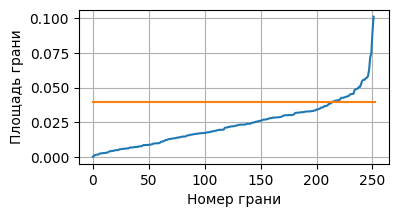

In [70]:
treshold = 0.04

a = mesh.areas.tolist()
b = sorted([[a[i][0], i] for i in range(N)])
areas = [i[0] for i in b]
id_s = [i[1] for i in b]
id_s_new = [i[1] for i in b if i[0]>treshold]
print(f"Найдено {len(id_s_new)} граней, больше {treshold}")

plt.figure(figsize=(4, 2))
plt.plot(areas)
plt.plot([0, N], [treshold, treshold])
plt.xlabel("Номер грани")
plt.ylabel("Площадь грани")
plt.grid()
plt.show()

In [87]:
print("```stl\nsolid cube_corner")
for i in id_s_new:
    n = numpy.array(mesh.normals[i].tolist())
    n = n/numpy.linalg.norm(n)
    v = mesh.points[i].tolist()
    print(f"  facet normal {n[0]} {n[1]} {n[1]}")
    print(f"    outer loop")
    for j in range(3):
        print(f"      vertex {v[3*j+0]} {3*j+v[1]} {3*j+v[1]}")
    print(f"    endloop")
    print(f"  endfacet")
print("endsolid\n```")

```stl
solid cube_corner
  facet normal -0.042495142807317685 0.2479986970659082 0.2479986970659082
    outer loop
      vertex -0.5284862518310547 0.11978214979171753 0.11978214979171753
      vertex -0.05537664145231247 3.1197821497917175 3.1197821497917175
      vertex -0.7566593289375305 6.1197821497917175 6.1197821497917175
    endloop
  endfacet
  facet normal -0.29620060607046694 0.6788292584713769 0.6788292584713769
    outer loop
      vertex -0.12027574330568314 0.5167943239212036 0.5167943239212036
      vertex -0.3808383643627167 3.5167943239212036 3.5167943239212036
      vertex -0.39563265442848206 6.516794323921204 6.516794323921204
    endloop
  endfacet
  facet normal 0.37864925283490947 -0.9254480518161156 -0.9254480518161156
    outer loop
      vertex 0.252174973487854 -0.44523531198501587 -0.44523531198501587
      vertex 0.010339483618736267 2.554764688014984 2.554764688014984
      vertex 0.2869337499141693 5.554764688014984 5.554764688014984
    endloop
  endfac

In [77]:
i = 0
mesh.points[i].tolist()

[-0.12795400619506836,
 0.5797331929206848,
 -0.3254646062850952,
 -0.12027574330568314,
 0.5167943239212036,
 -0.5346047878265381,
 -0.39563265442848206,
 0.5270012021064758,
 -0.4029051661491394]

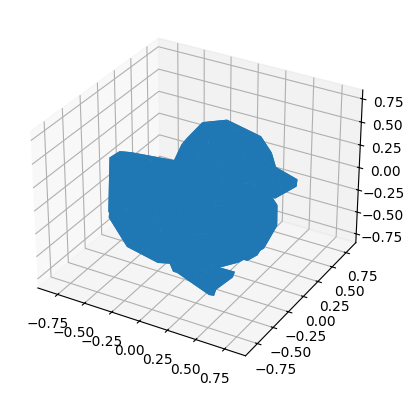

In [79]:
from mpl_toolkits import mplot3d
from matplotlib import pyplot

figure = pyplot.figure()
axes = figure.add_subplot(projection='3d')

axes.add_collection3d(mplot3d.art3d.Poly3DCollection(mesh.vectors))

scale = mesh.points.flatten()
axes.auto_scale_xyz(scale, scale, scale)

# Show the plot to the screen
pyplot.show()